In [33]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from lameg.surf import create_surf_gifti
from lameg.viz import show_surface, color_map, rgbtoint
from lameg.util import get_bigbrain_layer_boundaries, load_meg_sensor_data, convert_native_to_fsaverage
from scipy.signal import correlate
import io
from PIL import Image
from base64 import b64decode

import scipy.io as sio
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

In [34]:
data=sio.loadmat('/home/bonaiuto/visual_laminar/aligned_V1_ERF_FE_ps5.mat')

In [35]:
list(data.keys())

['__header__',
 '__version__',
 '__globals__',
 'la_aligned_rh_prior_ts',
 'la_aligned_lh_prior_ts',
 'la_aligned_rh_F_diff',
 'la_aligned_rh_layer_F_diff',
 'la_aligned_lh_F_diff',
 'la_aligned_lh_layer_F_diff',
 'ra_aligned_rh_prior_ts',
 'ra_aligned_lh_prior_ts',
 'ra_aligned_rh_F_diff',
 'ra_aligned_rh_layer_F_diff',
 'ra_aligned_lh_F_diff',
 'ra_aligned_lh_layer_F_diff',
 'wois',
 'ts_time']

In [36]:
contra_f=np.mean(np.stack([data['la_aligned_rh_layer_F_diff'], data['ra_aligned_lh_layer_F_diff']]),axis=0)
contra_f_diff=np.zeros(contra_f.shape)
for s in range(contra_f.shape[0]):
    for t in range(contra_f.shape[-1]):
        contra_f_diff[s,:,t]=contra_f[s,:,t]-np.min(contra_f[s,:,t])
ipsi_f=np.mean(np.stack([data['la_aligned_lh_layer_F_diff'], data['ra_aligned_rh_layer_F_diff']]),axis=0)
ipsi_f_diff=np.zeros(ipsi_f.shape)
for s in range(ipsi_f.shape[0]):
    for t in range(ipsi_f.shape[-1]):
        ipsi_f_diff[s,:,t]=ipsi_f[s,:,t]-np.min(ipsi_f[s,:,t])

contra_ts=np.mean(np.stack([data['la_aligned_rh_prior_ts'], data['ra_aligned_lh_prior_ts']]),axis=0)
ipsi_ts=np.mean(np.stack([data['la_aligned_lh_prior_ts'], data['ra_aligned_rh_prior_ts']]),axis=0)

In [37]:
woi_win =   np.mean(data['wois'],axis=-1)
ts_time =  data['ts_time'][0,:]

In [48]:
sex_df=pd.read_csv('/home/bonaiuto/visual_laminar/sex_v1_all_hi_snr.csv')

In [41]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [42]:
data = sio.loadmat('/home/bonaiuto/visual_laminar/ERF_OverTime_F_contra_family_ps5.mat') # VBA results Contra
contra_bestModelOverTime = data['bestModelOverTime'].squeeze()
time = data['time'].squeeze()

In [43]:
time_lims=[-300,300]
woi_time=woi_win
t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
woi_win=woi_time[t_idx]

col_l = plt.cm.cool(np.linspace(0, 1, num=6))
layer_colors = col_l

color_model_1 = layer_colors[0:3].mean(axis=0)
color_model_2 = layer_colors[3]
color_model_3 = layer_colors[4:6].mean(axis=0)

model_colors = {
    1: color_model_1,
    2: color_model_2,
    3: color_model_3
}

mask_woi = (ts_time >= woi_win[0]) & (ts_time <= woi_win[-1])

time_woi = ts_time[mask_woi]
model_woi_c = contra_bestModelOverTime[mask_woi]

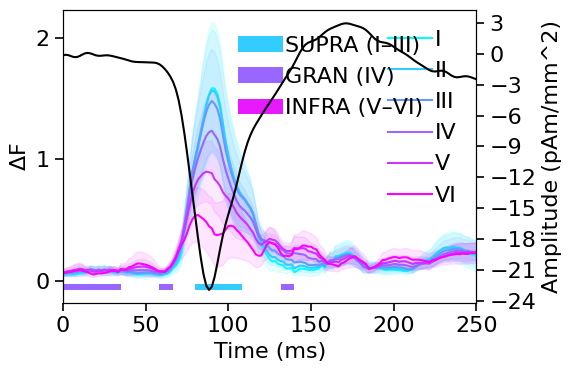

In [44]:
# Contra 
model_woi = model_woi_c

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)

l_labels = ['I', 'II', 'III', 'IV', 'V', 'VI']

contra_f_diff_mean=np.mean(contra_f_diff,axis=0)
contra_f_diff_se=np.std(contra_f_diff,axis=0)/np.sqrt(contra_f_diff.shape[0])
contra_ts_mean=np.mean(contra_ts,axis=0)

for i in range(6):
    ax.plot(
        woi_win,
        contra_f_diff_mean[i, :],
        label=l_labels[i],
        color=col_l[i]
    )
    ax.fill_between(
        woi_win, 
        contra_f_diff_mean[i,:]-contra_f_diff_se[i,:], 
        contra_f_diff_mean[i,:]+contra_f_diff_se[i,:], 
        color=col_l[i], 
        alpha=0.1
    )

#ax.axvline(x=0, color='k', linestyle='--')

leg_layers = ax.legend(loc='upper right', frameon=False)
ax.add_artist(leg_layers)


y_model = -0.05
start_idx = 0

for i in range(1, len(model_woi) + 1):
    if i == len(model_woi) or model_woi[i] != model_woi[start_idx]:
        model = model_woi[start_idx]
        if model != 0:
            t_start = time_woi[start_idx]
            t_end = time_woi[i - 1]
            ax.barh(
                y_model,
                width=t_end - t_start + np.median(np.diff(time_woi)),
                left=t_start,
                color=model_colors[model],
                height=0.05
            )
        start_idx = i


model_handles = [
    Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I–III)'),
    Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
    Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V–VI)')
]

ax.legend(
    handles=model_handles,
    loc='upper right',
    bbox_to_anchor=(0.92, 0.98),
    frameon=False
)


ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))


ax2 = ax.twinx()
ax2.plot(ts_time, contra_ts_mean*1000, 'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim([0, 250])
plt.tight_layout()

plt.savefig('./figure_09_visual_erf_contralateral_aligned.pdf')

In [51]:
data={
    'subject': [],
    'sex': [],
    'time': [],
    'lamina': [],
    'df': [],
}
for s_idx in range(contra_f_diff.shape[0]):
    for t_idx, t in enumerate(woi_win):
        for i in range(6):
            data['subject'].append(sex_df['subjectID'][s_idx])
            data['sex'].append(sex_df['sex'][s_idx])
            data['time'].append(t)
            data['lamina'].append(i)
            data['df'].append(contra_f_diff[s_idx,i,t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_09b_laminae.csv', index=False)

data={
    'subject': [],
    'sex': [],
    'time': [],
    'amp': []
}
for s_idx in range(contra_ts.shape[0]):
    for t_idx, t in enumerate(woi_win):
        data['subject'].append(sex_df['subjectID'][s_idx])
        data['sex'].append(sex_df['sex'][s_idx])
        data['time'].append(t)
        data['amp'].append(contra_ts[s_idx,t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_09b_prior_ts.csv', index=False)

data={
    'time': [],
    'model_woi': []
}
for t_idx, t in enumerate(woi_win):
    data['time'].append(t)
    data['model_woi'].append(model_woi[t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_09b_summary.csv', index=False)

In [52]:
data = sio.loadmat('/home/bonaiuto/visual_laminar/ERF_OverTime_F_ipsi_family_ps5.mat') # VBA results Contra
ipsi_bestModelOverTime = data['bestModelOverTime'].squeeze()
time = data['time'].squeeze()

In [53]:
time_lims=[-300,300]
woi_time=woi_win
t_idx=np.where((woi_time>=time_lims[0]) & (woi_time<=time_lims[1]))[0]
woi_win=woi_time[t_idx]

col_l = plt.cm.cool(np.linspace(0, 1, num=6))
layer_colors = col_l

color_model_1 = layer_colors[0:3].mean(axis=0)
color_model_2 = layer_colors[3]
color_model_3 = layer_colors[4:6].mean(axis=0)

model_colors = {
    1: color_model_1,
    2: color_model_2,
    3: color_model_3
}

mask_woi = (ts_time >= woi_win[0]) & (ts_time <= woi_win[-1])

time_woi = ts_time[mask_woi]
model_woi_c = ipsi_bestModelOverTime[mask_woi]

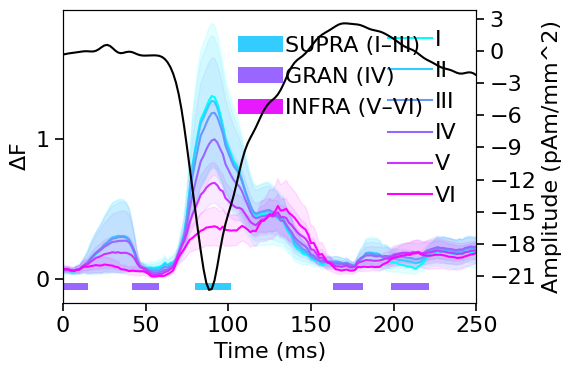

In [54]:
# Ipsi
model_woi = model_woi_c

fig=plt.figure(figsize=(6,4))

ax=plt.subplot(1,1,1)

l_labels = ['I', 'II', 'III', 'IV', 'V', 'VI']

ipsi_f_diff_mean=np.mean(ipsi_f_diff,axis=0)
ipsi_f_diff_se=np.std(ipsi_f_diff,axis=0)/np.sqrt(ipsi_f_diff.shape[0])
ipsi_ts_mean=np.mean(ipsi_ts,axis=0)

for i in range(6):
    ax.plot(
        woi_win,
        ipsi_f_diff_mean[i, :],
        label=l_labels[i],
        color=col_l[i]
    )
    ax.fill_between(
        woi_win, 
        ipsi_f_diff_mean[i,:]-ipsi_f_diff_se[i,:], 
        ipsi_f_diff_mean[i,:]+ipsi_f_diff_se[i,:], 
        color=col_l[i], 
        alpha=0.1
    )

#ax.axvline(x=0, color='k', linestyle='--')

leg_layers = ax.legend(loc='upper right', frameon=False)
ax.add_artist(leg_layers)


y_model = -0.05
start_idx = 0

for i in range(1, len(model_woi) + 1):
    if i == len(model_woi) or model_woi[i] != model_woi[start_idx]:
        model = model_woi[start_idx]
        if model != 0:
            t_start = time_woi[start_idx]
            t_end = time_woi[i - 1]
            ax.barh(
                y_model,
                width=t_end - t_start + np.median(np.diff(time_woi)),
                left=t_start,
                color=model_colors[model],
                height=0.05
            )
        start_idx = i


model_handles = [
    Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I–III)'),
    Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
    Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V–VI)')
]

ax.legend(
    handles=model_handles,
    loc='upper right',
    bbox_to_anchor=(0.92, 0.98),
    frameon=False
)


ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'$\Delta$F')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax2 = ax.twinx()
ax2.plot(ts_time, ipsi_ts_mean*1000, 'k')
ax2.set_ylabel('Amplitude (pAm/mm^2)')
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlim([0, 250])
plt.tight_layout()
plt.savefig('./figure_S15_visual_erf_ipsilateral_aligned.pdf')

In [56]:
data={
    'subject': [],
    'sex': [],
    'time': [],
    'lamina': [],
    'df': []
}
for s_idx in range(ipsi_f_diff.shape[0]):
    for t_idx, t in enumerate(woi_win):
        for i in range(6):
            data['subject'].append(sex_df['subjectID'][s_idx])
            data['sex'].append(sex_df['sex'][s_idx])
            data['time'].append(t)
            data['lamina'].append(i)
            data['df'].append(ipsi_f_diff[s_idx,i,t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_S15b_laminae.csv', index=False)

data={
    'subject': [],
    'sex': [],
    'time': [],
    'amp': []
}
for s_idx in range(ipsi_ts.shape[0]):
    for t_idx, t in enumerate(woi_win):
        data['subject'].append(sex_df['subjectID'][s_idx])
        data['sex'].append(sex_df['sex'][s_idx])
        data['time'].append(t)
        data['amp'].append(ipsi_ts[s_idx,t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_S15b_prior_ts.csv', index=False)

data={
    'time': [],
    'model_woi': []
}
for t_idx, t in enumerate(woi_win):
    data['time'].append(t)
    data['model_woi'].append(model_woi[t_idx])
df=pd.DataFrame(data)
df.to_csv(f'source_data_fig_S15b_summary.csv', index=False)